# Import library

In [1]:
import time
import os
import os
import dagshub
import mlflow
import torch
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings

# Global setting

In [2]:
# ML Flow dan DagsHub Integration
dagshub.init(repo_owner='abiyamf', repo_name='thesis', mlflow=True)
settings.update({"mlflow": True})

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/thesis"

Repository abiyamf/thesis initialized!

In [3]:
os.environ["MLFLOW_KEEP_RUN_ACTIVE"] = "True"
gpu_name = torch.cuda.get_device_name(0)

def format_duration(seconds: float) -> str:
    """Convert seconds into 'Hh Mm Ss' format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours}h {minutes}m {secs}s"

def save_class_metrics(val_results, mode):
    # Ambil nama class
    names = val_results.names

    # Data per-class
    data = {
        "class": [names[i] for i in range(len(names))],
        "precision": val_results.box.p.tolist(),
        "recall": val_results.box.r.tolist(),
        "mAP50-box": val_results.box.ap50.tolist(),
        "mAP50-95-box": val_results.box.maps.tolist(),
        "mAP50-mask": val_results.seg.ap50.tolist(),
        "mAP50-95-mask": val_results.seg.maps.tolist(),
    }

    # Tambahkan baris agregat "all"
    all_row = {
        "class": "all",
        "precision": float(val_results.box.mp),
        "recall": float(val_results.box.mr),
        "mAP50-box": float(val_results.box.map50),
        "mAP50-95-box": float(val_results.box.map),
        "mAP50-mask": float(val_results.seg.map50),
        "mAP50-95-mask": float(val_results.seg.map),
    }

    for key in data.keys():
        data[key].insert(0, all_row[key])

    # Buat DataFrame dan simpan
    df = pd.DataFrame(data)
    csv_path = os.path.join(str(val_results.save_dir), f"class_metrics_{mode}.csv")
    df.to_csv(csv_path, index=False)

    return csv_path

# Yolov8

In [4]:
# Variabel Global
projectType = "yolo_version_segmentation_comparison_experiment"
imgsz = 640
models = ['yolov8n-seg.pt','yolov8s-seg.pt','yolov8m-seg.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
project_base_objectDetection_all_class = "results/yolo_v8"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 02:09:08 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo_version_segmentation_comparison_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum

# Yolov9

In [6]:
# Terlalu berat

# Yolov11

In [4]:
# Variabel Global
projectType = "yolo_version_segmentation_comparison_experiment"
imgsz = 640
models = ['yolo11n-seg.pt','yolo11s-seg.pt','yolo11m-seg.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
project_base_objectDetection_all_class = "results/yolo_v11"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum

# Yolov12

In [6]:
# Variabel Global
projectType = "yolo_version_segmentation_comparison_experiment"
imgsz = 640
models = ['yolo12n-seg.yaml','yolo12s-seg.yaml','yolo12m-seg.yaml']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
project_base_objectDetection_all_class = "results/yolo_v12"

In [7]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-seg.yaml, moment

# Graph comparison

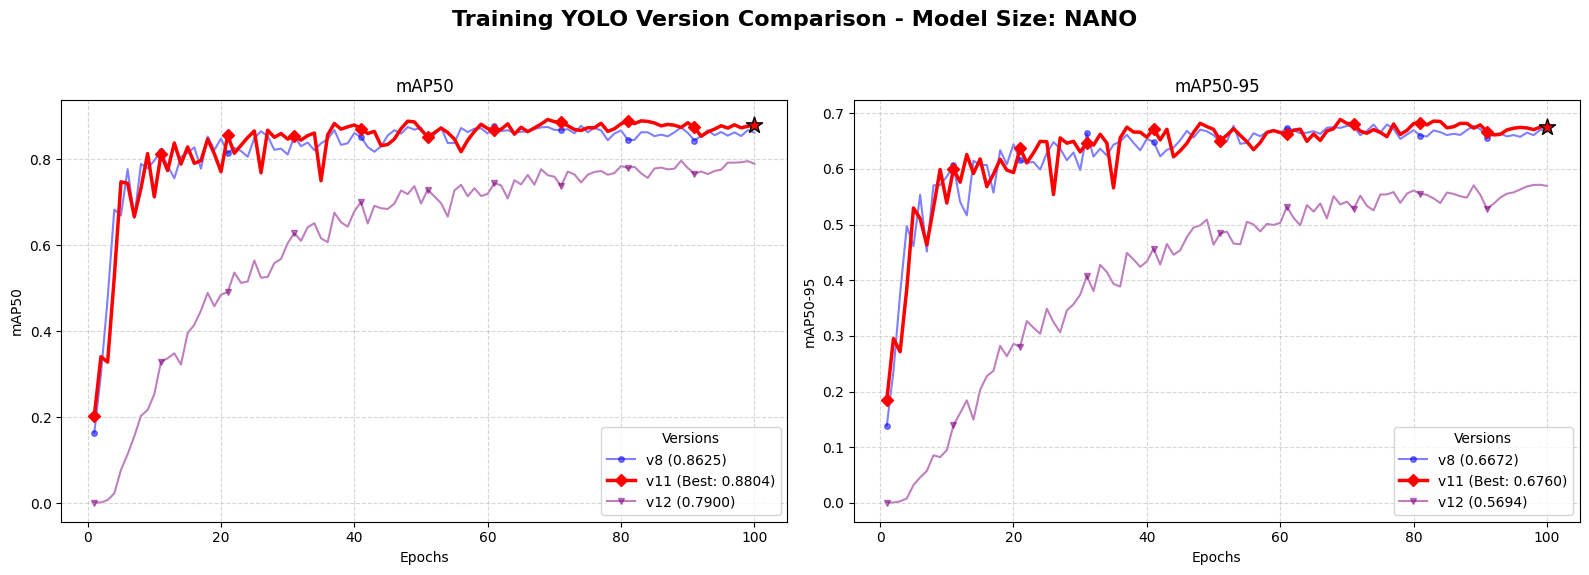

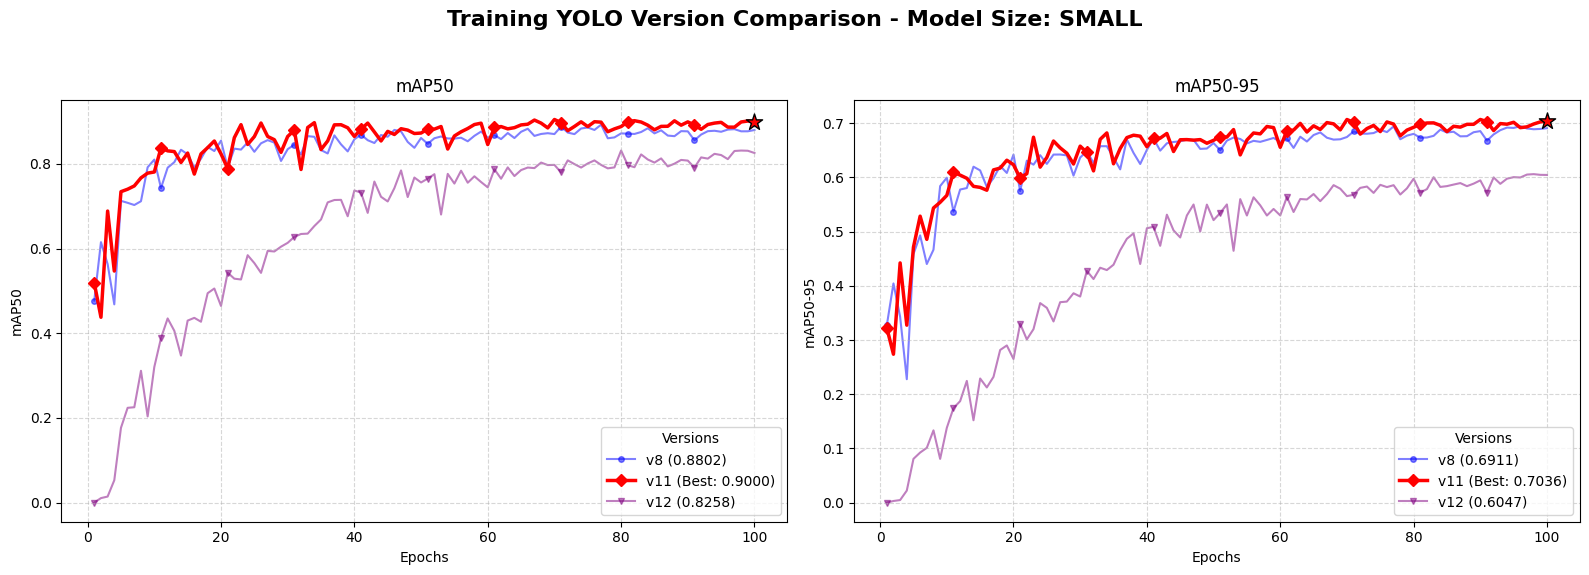

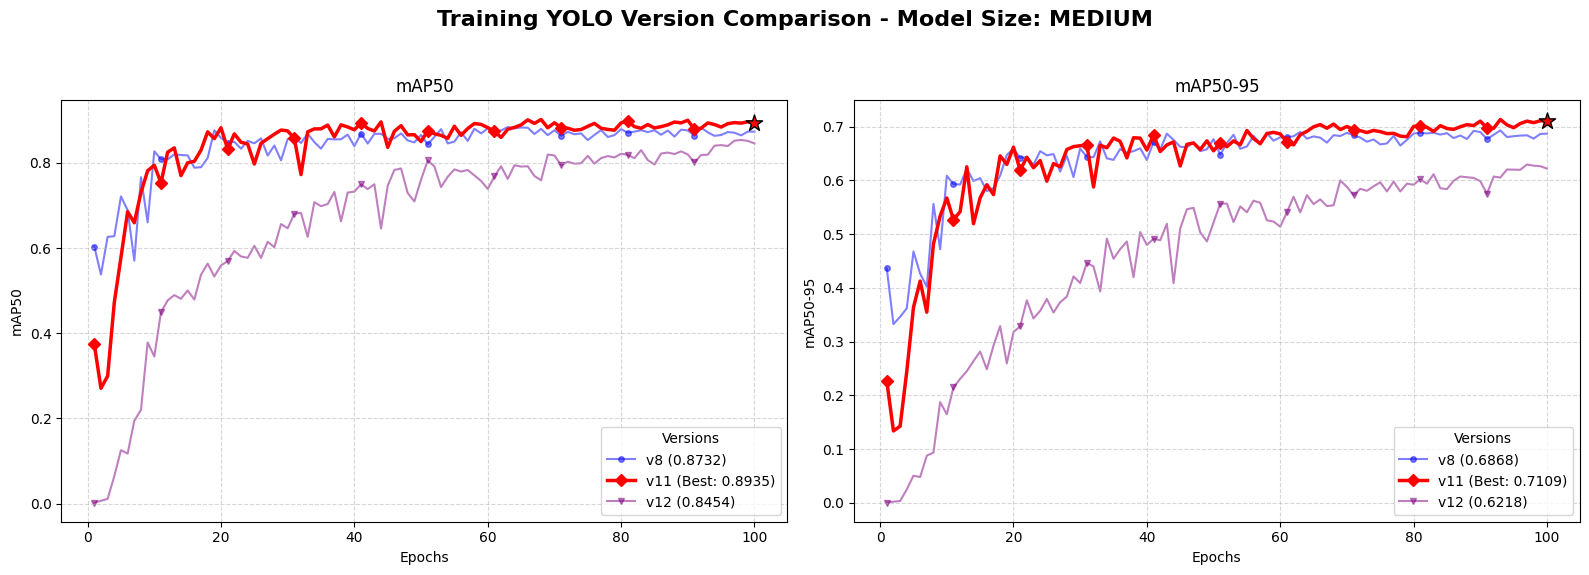

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. KONFIGURASI ---
base = Path("results")
versions = ["yolo_v8", "yolo_v11", "yolo_v12"]
sizes = ["nano", "small", "medium"]

# Map nama kolom di CSV results.csv Ultralytics
metric_map = {
    "mAP50": "metrics/mAP50(M)",
    "mAP50-95": "metrics/mAP50-95(M)",
}

# Konfigurasi Style (Warna & Simbol) sesuai request
style_config = {
    "yolo_v8":  {"color": "blue",   "marker": "o", "label": "v8"},  # Circle
    "yolo_v11": {"color": "red",    "marker": "D", "label": "v11"}, # Diamond
    "yolo_v12": {"color": "purple", "marker": "v", "label": "v12"}  # Inverted Triangle
}

# --- 2. LOOPING UTAMA (BERDASARKAN SIZE) ---
# Kita ingin 3 Figure terpisah: Satu untuk Nano, Satu Small, Satu Medium
for size in sizes:
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Training YOLO Version Comparison - Model Size: {size.upper()}", fontsize=16, fontweight='bold')

    # Loop untuk Subplot (mAP50 dan mAP50-95)
    for idx, (metric_name, metric_col) in enumerate(metric_map.items()):
        ax = axes[idx]
        
        loaded_data = []

        # --- 3. LOAD DATA DARI SETIAP VERSION ---
        for ver in versions:
            # Asumsi struktur folder: results/yolo_v8/training/nano/results.csv
            csv_path = base / ver / "training" / size / "results.csv"

            if not csv_path.exists():
                print(f"[SKIP] File not found: {csv_path}")
                continue

            try:
                df = pd.read_csv(csv_path)
                # Bersihkan spasi di nama kolom
                df.columns = [c.strip() for c in df.columns]

                if metric_col in df.columns:
                    final_val = df[metric_col].iloc[-1]
                    loaded_data.append({
                        "version": ver,
                        "epochs": df["epoch"],
                        "values": df[metric_col],
                        "final_value": final_val
                    })
                else:
                    print(f"[WARN] Metric {metric_col} not found in {ver}/{size}")

            except Exception as e:
                print(f"[ERR] Error reading {csv_path}: {e}")

        # Jika tidak ada data sama sekali untuk metric ini, skip
        if not loaded_data:
            continue

        # --- 4. TENTUKAN NILAI TERTINGGI (BEST MODEL) ---
        best_run = max(loaded_data, key=lambda x: x['final_value'])
        best_version_name = best_run['version']

        # --- 5. PLOTTING ---
        for data in loaded_data:
            ver_name = data['version']
            style = style_config.get(ver_name, {"color": "gray", "marker": "."})
            
            is_best = (ver_name == best_version_name)

            # Logika Highlight vs Fade
            if is_best:
                alpha = 1.0
                linewidth = 2.5
                zorder = 10
                label_text = f"{style['label']} (Best: {data['final_value']:.4f})"
            else:
                alpha = 0.5
                linewidth = 1.5
                zorder = 1
                label_text = f"{style['label']} ({data['final_value']:.4f})"

            # Plot Garis
            ax.plot(
                data['epochs'], 
                data['values'], 
                label=label_text,
                color=style['color'],
                linewidth=linewidth,
                alpha=alpha,
                zorder=zorder,
                marker=style['marker'],
                markevery=len(data['epochs']) // 10 if len(data['epochs']) > 10 else 1, # Agar marker tidak menumpuk
                markersize=6 if is_best else 4
            )

            # Tambahkan Highlight Titik Terakhir untuk Pemenang
            if is_best:
                ax.scatter(
                    data['epochs'].iloc[-1],
                    data['final_value'],
                    color=style['color'],
                    s=150,
                    edgecolor='black',
                    marker='*', # Bintang untuk menandai endpoint juara
                    zorder=11
                )

        # Styling Axes
        ax.set_title(f"{metric_name}", fontsize=12)
        ax.set_xlabel("Epochs")
        ax.set_ylabel(metric_name)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Versions")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

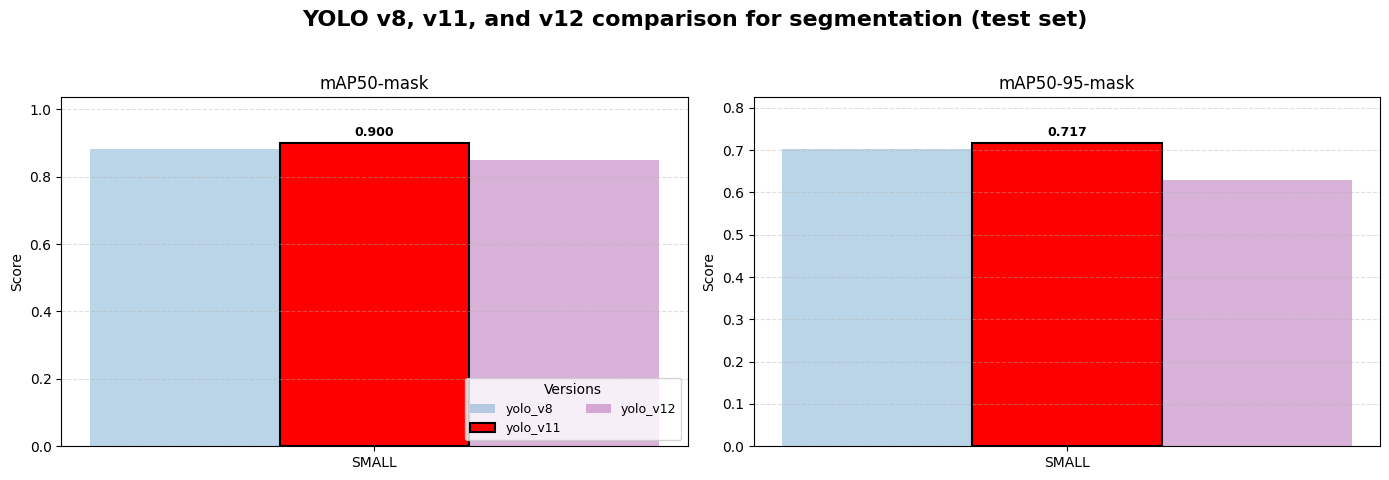

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURASI ---
base = Path("results")
versions = ["yolo_v8", "yolo_v11", "yolo_v12"]
# variants = ["nano", "small", "medium"]
variants = ["small"]

# Palette warna disamakan dengan request sebelumnya
colors = {
    "yolo_v8":  "#1f77b4", # Blue
    "yolo_v9":  "green",   # Green (disamakan dgn sebelumnya)
    "yolo_v10": "orange",  # Orange (disamakan dgn sebelumnya)
    "yolo_v11": "red",     # Red
    "yolo_v12": "purple",  # Purple
}

def load_all_row(csv_path):
    df = pd.read_csv(csv_path)
    # Bersihkan nama kolom dari spasi berlebih
    df.columns = [c.strip() for c in df.columns]
    
    # Filter class 'all'
    row = df[df["class"] == "all"]
    if row.empty:
        raise ValueError(f"Missing Class == 'all' in {csv_path}")
    return row.iloc[0]

# --- 2. PERSIAPAN DATA ---
# Kita bangun DataFrame besar agar mudah diakses saat plotting
data = {"variant": variants}
metrics_list = ["mAP50-mask", "mAP50-95-mask"]

for metric in metrics_list:
    for v in versions:
        vals = []
        for variant in variants:
            # Path disesuaikan: results/v/validation/variant/...
            csv_path = base / v / "validation" / variant / "class_metrics_validation.csv"
            
            if not csv_path.exists():
                print(f"[SKIP] Missing: {csv_path}")
                vals.append(np.nan)
                continue
            
            try:
                r = load_all_row(csv_path)
                vals.append(float(r[metric]))
            except Exception as e:
                print(f"[ERR] Error reading {csv_path}: {e}")
                vals.append(np.nan)
        
        data[f"{v}_{metric}"] = vals

df = pd.DataFrame(data)

# --- 3. PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("YOLO v8, v11, and v12 comparison for segmentation (test set)", fontsize=16, fontweight='bold')

x = np.arange(len(variants))
bar_w = 0.15 # Lebar bar

for ax, metric in zip(axes, metrics_list):
    
    # Cari nilai tertinggi per variant untuk highlight
    best_per_variant = {}
    for vi, variant in enumerate(variants):
        best_v = None
        best_val = -1
        for v in versions:
            val = df.loc[vi, f"{v}_{metric}"]
            if pd.notna(val) and val > best_val:
                best_val = val
                best_v = v
        best_per_variant[variant] = best_v

    # Loop versi untuk membuat Bar Group
    for i, v in enumerate(versions):
        vals = df[f"{v}_{metric}"].values

        # Logic Styling per Bar
        # Kita harus loop per variant (vi) karena status highlight berbeda tiap ukuran
        for vi, val in enumerate(vals):
            if pd.isna(val): continue

            is_winner = (best_per_variant[variants[vi]] == v)
            
            # Style: Pemenang Jelas, Kalah Pudar
            alpha = 1.0 if is_winner else 0.3
            edgecolor = 'black' if is_winner else 'none'
            linewidth = 1.5 if is_winner else 0
            
            # Posisi X Bar
            x_pos = x[vi] + (i - (len(versions)-1)/2) * bar_w
            
            bar = ax.bar(
                x_pos,
                val,
                width=bar_w,
                color=colors.get(v, "gray"),
                alpha=alpha,
                edgecolor=edgecolor,
                linewidth=linewidth,
                label=v if vi == 0 else "" # Label legend hanya sekali
            )

            # Annotasi Text hanya untuk Pemenang
            if is_winner:
                ax.text(
                    x_pos,
                    val + 0.01,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight='bold',
                    color='black'
                )

    # Estetika Grafik
    ax.set_title(f"{metric}", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([v.upper() for v in variants])
    ax.set_ylabel("Score")
    
    # Set Y Limit sedikit lebih tinggi agar text tidak terpotong
    max_val_in_plot = df[[c for c in df.columns if metric in c]].max().max()
    ax.set_ylim(0, max_val_in_plot * 1.15) 
    
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    
    # Legend ditaruh di luar atau tempat kosong
    if metric == metrics_list[0]: # Taruh legend di plot pertama saja atau keduanya
        ax.legend(title="Versions", loc="lower right", ncol=len(versions)//2 + 1, fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('graph_output/yolo_v8-11-12_comparison_for_segmentation_testset.png', dpi=300)
plt.show()